## Import library

In [1]:
import warnings
import sys
import os
warnings.filterwarnings('ignore')
sys.path.append('../')
from timeit import default_timer
import matplotlib.pyplot as plt
import numpy as np
from utils import *
import cigsegy
from cigsegy import SegyNP
import time

## Load 3D seismic data

In [2]:
## path of field seismic data
F3_path = '/home/g202393750/Documents/ML-UFNO-3D-Seis-Recon-main/data/F3_Seismic_data.sgy' # Here you need to change the patch to your own folder

## read the trace header of the SEGY files
cigsegy.textual_header(f'{F3_path}')

               ?       ?_ |  >            /         (/`                         
           `             _?        / > >                                        
       / / >/_          _    / /                                                
       ?_ ?> >       ?_ ?> >                                                    
                                                                                
       ? >                                     <        <                       
       ? >                                     <        <                       
       ? >                                     <        <                       
       ? >                                     <        <                       
        >   :                   _                                               
      & ?|    ?>  $ &        )          ( :?>    +                              
                                                                                
       > % >                

In [3]:
## check the acquisition info of the 3D seismic dta
cigsegy.metaInfo(f'{F3_path}')

In python, the shape is (n-inline, n-crossline, n-time) = (651, 951, 462).

shape: (n-time, n-crossline, n-inline) = (462, 951, 651)
trace sorting code: 4 - Horizontally stacked
sample interval: 4000, data format code: 3 = 2-byte, two's complement integer
inline range: 100 - 750, crossline range: 300 - 1250
interval of inline: 25.0, interval of crossline: 25.0, time start: -4
inline field: 189, crossline field: 193
inline step: 1, crossline step: 1
Is regular file (no missing traces): false


In [4]:
## load seismic data
f3_data = SegyNP(f'{F3_path}')
print(f'Shape of F3 data: {f3_data.shape}')

# Data normalization & QC (cut the blank part of the seismic cubes)
norm_f3_data = data_norm(f3_data[:600, :, :])

Shape of F3 data: (651, 951, 462)
min : -13.154744148254395, max : 13.156721115112305, mean : 4.289474553331729e-09, std : 0.9999995231628418


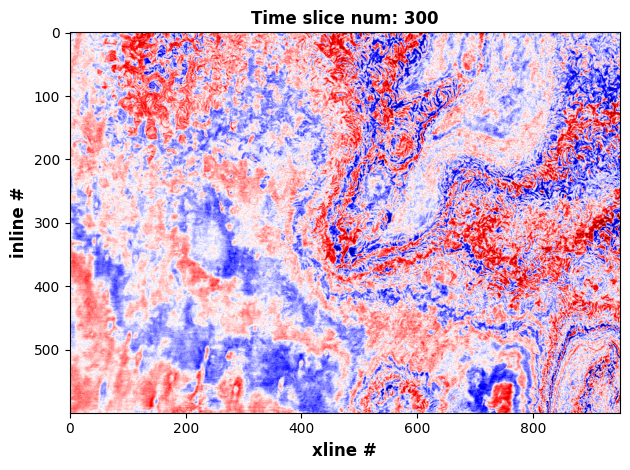

In [5]:
## Visualize the time slice of the first field seismic data
v=5
time_num = 300
plt.figure()
plt.imshow(norm_f3_data[:, :, time_num], cmap='seismic', vmax=v, vmin=-v, aspect='auto')
plt.xlabel('xline #', fontweight='bold', fontsize=12)
plt.ylabel('inline #', fontweight='bold', fontsize=12)
plt.title(f'Time slice num: {time_num}', fontweight='bold')
plt.tight_layout()
# plt.savefig(fname=f'./Figs/Filt_mig_data_time_slice_num{time_num}.png',format='png',dpi=300)

## Extracting Patches

In [6]:
## patch size of 3D cubes
l1=128
l2=128
l3=128

## Slide size of 3D cubes
s1=100
s2=100
s3=100

## 3D patching 
print('----------------F3 data patching begin------------------')
tic_f3 = time.time()
f3_patches = patch3d(np.array(norm_f3_data), l1=l1, l2=l2, l3=l3, s1=s1, s2=s2, s3=s3, mode=1)
toc_f3 = time.time()
print(f'----------------F3 data patching finish: {toc_f3 - tic_f3:.4f} s------------------')

----------------F3 data patching begin------------------
----------------F3 data patching finish: 99.0845 s------------------


In [7]:
## Define a function to filter out those patches with zero values
def filter_cubes_by_zero_count(cubes, threshold=10):
    """
    Filters 3D cubes by the count of zero values.

    Parameters:
        cubes (np.ndarray): A 4D array of shape (nz, nx, ny, num_cubes) representing the 3D cubes.
        threshold (int): The maximum number of zero values allowed in a cube to keep it.

    Returns:
        np.ndarray: A filtered 4D array of cubes with zero values <= threshold.
    """
    filtered_cubes = []
    for i in range(cubes.shape[3]):
        zero_count = np.sum(cubes[:, :, :, i] == 0)  # Count zero values in the current cube
        if zero_count <= threshold:
            filtered_cubes.append(cubes[:, :, :, i])  # Keep the cube if zeros <= threshold
    
    return np.array(filtered_cubes)

In [8]:
## Feature selection: 

## Convert from (l1*l2*l3, num_patch) -> (l1, l2, l3, num_patch)
f3_patches_3d = np.reshape(f3_patches,(l1, l2, l3, f3_patches.shape[1]))


## remove those with zeros
filtered_f3_patches = filter_cubes_by_zero_count(f3_patches_3d, threshold=50)
print(filtered_f3_patches.shape)
# filtered_moomba_patches.shape

(180, 128, 128, 128)


In [9]:
## Save the result
np.save(f"/home/g202393750/Documents/ML-UFNO-3D-Seis-Recon-main/data/F3_filtered_patch_data_{l1}_{l2}_{l3}.npy", filtered_f3_patches)